# Adding Cloud-Native Capabilities to an Archival Dataset

**Author**: Tony Castrononva \<acastronova@cuahsi.org\>  
**Last Modified**: 08.01.2025  
**Purpose**: Modern science studies required the archival and publishing of research data to align with best practices of data management and FAIR data principles. These data provide a necessary starting point for peers to reuse, reproduce, and advance scientific publications. Moreover, it's often necessary to archive such data in the native format in which they were produced; and archival format. These archival formats are not always ideal for analysis using modern cloud infrastructure and tools. This notebook demonstrates how an archival format, e.g. the outputs of a model simulation in the NetCDF format, can be enhanced for use in cloud workflows by leveraging HydroShare's new cloud-native infrastructure.


Import the necessary libaries for this notebook. Below are several notes about these libraries.

* `S3hsclient` - an extension to the CUAHSI `hsclient` that facilitates direct S3 access to data.
* `kerchunk` - a software library for enabling efficient access to data from traditional formats (e.g. NetCDF, GRIB2, TIFF)
* `fsspec` - provides a pythonic interface to remote files systems, such as CUAHSI's HydroShare S3 backend.
* `xarray` - provides easy access to multidimensional datasets.

In [29]:
#import importlib

import os
import time
import json
import logging
import zipfile
import warnings
import urllib.request
from tqdm import tqdm
from pathlib import Path
from datetime import datetime

import xarray
import fsspec
import pandas as pd
import kerchunk.hdf
import S3hsclient as hsclient

First we need to download test data. The following cell will collect data from an existing HydroShare resource containing simulation outputs for a WRF-Hydro simulation in Iowa. These data have been stored in a compressed format due to prior limitations of the HydroShare system. We'll modify these data to provide cloud-native access to them using the latest advancements to the HydroShare system.

In [ ]:
url = 'https://www.hydroshare.org/resource/77f0aca372074078ad61855d081ee505/data/contents/OUTPUT.zip'
urllib.request.urlretrieve(url, 'OUTPUT.zip')

# extract into a directory called "OUTPUT"
with zipfile.ZipFile('OUTPUT.zip', 'r') as zip_ref:
    zip_ref.extractall()

List the number of files in this directory.

In [ ]:
num_files = len(list(Path('OUTPUT').glob('*')))
print(f'Found {num_files} files in the "OUTPUT" directory')

These files are stored using 4 different postfixes, each describing a different category of simulation output: 

* LDASOUT - Land and surface flux outputs  
* RTOUT - Surface water routing outputs  
* CHRTOUT - Channel routing outputs  
* GWOUT - Groundwater outputs

Moreover, for each category of outputs there exist one file per simulation timestep. To reduce the number of files, and improve the efficiency of data access, we'll merge these data. Since the organization of files writted to disk will define the data chunks when accessing these data using cloud native software libraries, we will adhere to the `Xarray` guidelines that suggest a minimum of one million elements per chunk. Since we're not dealing with a large amount of data here, we can simply merge all of the time-step files into one file for each component of the output. While this can be done using python libraries such as `Xarray`, it is far more efficient to use the `NCO` bash tools. `NCO` tools must be installed on your system, see the following for installation instructions: [NCO Homepage](https://nco.sourceforge.net/).

In [2]:
# make a new directory for our merged output
os.makedirs('merged_OUTPUT', exist_ok=True)

# combine timestep files into a single file
print('Merging LDASOUT files...', flush=True, end='')
!ncrcat -O OUTPUT/*LDASOUT* merged_OUTPUT/LDASOUT.nc
print('done')

print('Merging RTOUT files...', flush=True, end='')
!ncrcat -O OUTPUT/*.RTOUT* merged_OUTPUT/RTOUT.nc
print('done')

print('Merging CHRTOUT files...', flush=True, end='')
!ncecat -O -u time OUTPUT/*CHRTOUT* merged_OUTPUT/CHRTOUT.nc
print('done')

print('Merging GWOUT files...', flush=True, end='')
!ncecat -O -u time OUTPUT/*GWOUT* merged_OUTPUT/GWOUT.nc
print('done')

Merging LDASOUT files...done
Merging RTOUT files...done
Merging CHRTOUT files...done
Merging GWOUT files...done


In [5]:
# fix the time concatenation

start = pd.Timestamp("2018-06-01 01:00:00")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for f in ['merged_OUTPUT/CHRTOUT.nc',
              'merged_OUTPUT/GWOUT.nc']:
        print(f'\nProcessing {f}', flush=True, end='')
        
        print('  Loading Dataset...', flush=True, end='')
        ds = xarray.open_dataset(f)
        print('done')
        
        print('  Fixing Time Coordinate...', flush=True, end='')
        ds = ds.assign_coords(time=pd.date_range(start, periods=ds.sizes["time"], freq="h"))
        print('done')
        
        print('  Saving to temp file...', flush=True, end='')
        ds.to_netcdf('merged_OUTPUT/temp.nc')
        ds.close()
        print('done')
        
        print('  Replacing original file...', flush=True, end='')
        os.replace('merged_OUTPUT/temp.nc', f)
        print('done')


Processing merged_OUTPUT/CHRTOUT.nc  Loading Dataset...done
  Fixing Time Coordinate...done
  Saving to temp file...done
  Replacing original file...done

Processing merged_OUTPUT/GWOUT.nc  Loading Dataset...done
  Fixing Time Coordinate...done
  Saving to temp file...done
  Replacing original file...done


To improve the performance of our data, we'll define data chunks and save them to the NetCDF4 file. This can drastically improve data read speeds which makes our data more accessible for cloud workflows and analyses.

Define a helper function to assist with creating chunk encodings.

In [9]:
def build_encoding(ds, compress=True, complevel=4):
    encoding = {}
    for var_name, var in ds.data_vars.items():

        # skip crs
        if var_name == "crs":
            encoding[var_name] = {}  # or omit zlib/compression
            continue
        
        # Build per-dimension chunk size: take the first chunk in each axis
        chunk_shape = tuple(
            chunks[0] if len(chunks) > 0 else ds.sizes[dim]
            for dim, chunks in zip(var.dims, var.chunks)
        )

        # Sanity check: must match number of dims
        if len(chunk_shape) != len(var.dims):
            raise ValueError(
                f"{var_name}: chunk_shape {chunk_shape} length {len(chunk_shape)} "
                f"does not match dims {var.dims} (length {len(var.dims)})"
            )

        enc = {"chunksizes": chunk_shape}
        if compress:
            enc.update({"zlib": True, "complevel": complevel})
        if "_FillValue" in var.attrs:
            enc["_FillValue"] = var.attrs["_FillValue"]

        encoding[var_name] = enc

    return encoding

def save_chunks_to_nc(ds, encoding, output_dir, original_file_name):
    
    # Write with explicit chunking
    ds.to_netcdf(
        f"{output_dir}/temp.nc",
        format="NETCDF4",
        engine="netcdf4",
        encoding=encoding,
    )

    # replace the original file
    os.replace(f"{output_dir}/temp.nc", f"{output_dir}/{original_file_name}")

In [10]:
%%time

# rechunk CHRTOUT
print('Rechunking CHRTOUT...', flush=True, end='')
ds = xarray.open_dataset('merged_OUTPUT/CHRTOUT.nc')
ds_rechunked = ds.chunk({'time':712, 'feature_id':555, 'reference_time':1})
encoding = build_encoding(ds_rechunked)
save_chunks_to_nc(ds_rechunked, encoding, 'merged_OUTPUT', 'CHRTOUT.nc')
print('done\n')

# rechunk GWOUT
print('Rechunking GWOUT...', flush=True, end='')
ds = xarray.open_dataset('merged_OUTPUT/GWOUT.nc')
ds_rechunked = ds.chunk({'time':712, 'feature_id':555, 'reference_time':1})
encoding = build_encoding(ds_rechunked)
save_chunks_to_nc(ds_rechunked, encoding, 'merged_OUTPUT', 'GWOUT.nc')
print('done\n')

# rechunk RTOUT
print('Rechunking RTOUT...', flush=True, end='')
ds = xarray.open_dataset('merged_OUTPUT/RTOUT.nc')
ds_rechunked = ds.chunk({'time':712, 'x':152, 'y':48, 'soil_layers_stag':4, 'reference_time':1})
encoding = build_encoding(ds_rechunked)
save_chunks_to_nc(ds_rechunked, encoding, 'merged_OUTPUT', 'RTOUT.nc')
print('done\n')

# rechunk LDASOUT
print('Rechunking LDASOUT...', flush=True, end='')
ds = xarray.open_dataset('merged_OUTPUT/LDASOUT.nc')
ds_rechunked = ds.chunk({'time':712, 'x':38, 'y':12, 'soil_layers_stag':4, 'snow_layers':3, 'reference_time':1})
encoding = build_encoding(ds_rechunked)
save_chunks_to_nc(ds_rechunked, encoding, 'merged_OUTPUT', 'LDASOUT.nc')
print('done\n')

Rechunking CHRTOUT...done

Rechunking GWOUT...done

Rechunking RTOUT...done

Rechunking LDASOUT...done

CPU times: user 31 s, sys: 5.38 s, total: 36.4 s
Wall time: 36.7 s


Preview our new chunks. We need to pass `chunks={}` when opening the dataset to tell `xarray` to use the chunks encoded in the file saved to disk.

In [17]:
ds = xarray.open_dataset('merged_OUTPUT/CHRTOUT.nc', chunks={})

## Add NetCDF Files to HydroShare Resource

Now that we've saved our data into reasonably sized groupings, we add it to a HydroShare resource. We'll use the `S3hsclient` library to upload these files to a new resource.

In [30]:
# connect to HydroShare
host = 'beta.hydroshare.org'
hs = hsclient.S3HydroShare(host=host, log_level='INFO')

Username:  TonyCastronova
Password for TonyCastronova:  ········


2025-08-06 13:42:29,930 - S3hsclient.S3HydroShare - INFO - Getting S3 credentials


In [31]:
# # create a new HydroShare resource to store our data.
# resource = hs.create()
# resource_id = resource.resource_id

# print(f'Resource created at: https://{host}/resource/{resource_id}')

resource = hs.resource('f0d9a991e2844947bd1d742b08103399')

2025-08-06 13:42:57,758 - S3hsclient.S3HydroShare - INFO - resource_id=f0d9a991e2844947bd1d742b08103399
2025-08-06 13:42:57,951 - S3hsclient.S3HydroShare - INFO - s3Path =  tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/


In [13]:
# add metadata to this resource
resource.metadata.title = 'Simulation Outputs for Clearcreek Iowa'
resource.metadata.abstract = ('This resource contains WRF-Hydro (configured as the National Water Model) simulation '
                              'outputs for the Clearcreek watershed in Iowa. Zarr headers have been included to '
                              'facilitated cloud-native data access. The Zarr headers were created using the Kerchunk '
                              'Python library.')
resource.metadata.subjects = ['WRF-Hydro', 'Zarr', 'Kerchunk', 'Clearcreek']
resource.save()

In [14]:
# add the content files
resource_subdirectory = 'simulation_outputs'
for file in Path('merged_OUTPUT').glob('*.nc'):
    
    print(f'Adding {file} to {resource_subdirectory} files')
    
    resource.s3_put(file, prefix=resource_subdirectory+'/')

Adding merged_OUTPUT/CHRTOUT.nc to simulation_outputs files
Adding merged_OUTPUT/GWOUT.nc to simulation_outputs files
Adding merged_OUTPUT/RTOUT.nc to simulation_outputs files
Adding merged_OUTPUT/LDASOUT.nc to simulation_outputs files


In [15]:
# list the files in the HS resource.
# Notice that there are a number of additional files that have been created by HydroShare.
# These files provide metadata for representing the content of each file within the
# HydroShare system.
for path in resource.s3_ls(refresh=True):
    print(path)

for path in resource.s3_ls(resource_subdirectory, refresh=True):
    print(path)

tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/CHRTOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/GWOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/LDASOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/RTOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT.nc
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT_header_info.txt
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT_meta.xml
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT_resmap.xml
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/GWOUT.nc
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/GWOUT_header_

Notice that our resource contains more than just the NetCDF files that we uploaded. This is because HydroShare recognized them and extracted their metadata for use within the user interface. These metadata are stored in the additional files.

## Create Kerchunk JSON References

Create `Kerchunk` json headers for the files in our HydroShare resource to enable cloud-native access.

In [16]:
logging.getLogger("h5-to-zarr").setLevel(logging.WARNING)

# make a directory for our reference files
os.makedirs('references', exist_ok=True)

s3_fs = hs._hs_session.s3
files = resource.s3_ls(resource_subdirectory) 
matches = []
for f in files:
    # only consider files that end with .nc
    if f.endswith('.nc'):
        url = "s3://" + f
        print(f'Building references for {url}...', flush=True, end='')
        with s3_fs.open(url) as inf:
            h5chunks = kerchunk.hdf.SingleHdf5ToZarr(inf,
                                                     url,
                                                     inline_threshold=100,
                                                     error='warn')
            out = h5chunks.translate()
            
            with open('references/' + Path(url).stem + '_references.json', 'w') as f:
                json.dump(out, f, indent=4)
        print('done')

Building references for s3://tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT.nc...done
Building references for s3://tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/GWOUT.nc...done
Building references for s3://tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/LDASOUT.nc...done
Building references for s3://tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/RTOUT.nc...done


Add these reference files to the HydroShare resource. We can use the `put_many` function to bulk upload files.

In [17]:
ref_files = Path('references').glob('*.json')
file_strings = [str(f) for f in list(ref_files)]
resource.s3_put_many(file_strings, max_workers=10)

100%|███████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 11.65it/s]


Let's print all the data that exists in our HydroShare resource.

In [18]:
# loop over the folders in the resource and print the 
# files that exist within each folder.
for prefix in ['', 'simulation_outputs']:
    for path in resource.s3_ls(prefix=prefix):
        print(path)

tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/CHRTOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/GWOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/LDASOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/RTOUT_references.json
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT.nc
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT_header_info.txt
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT_meta.xml
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/CHRTOUT_resmap.xml
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/GWOUT.nc
tonycastronova/f0d9a991e2844947bd1d742b08103399/data/contents/simulation_outputs/GWOUT_header_

## Load Data via Kerchunked Reference File

Define a function that will load a `Kerchunk` reference file stored in a HydroShare resource. A few thinks to point out in the code block below: (1) s3 key and secret are obtained from our `hsclient` instance and provide the authentication needed to access our data files, and (2) the s3_path and host url are obtained from `hsclient` to build urls to the files of interest.

In [21]:
import fsspec

def load_kerchunk_from_hs(resource, filename):

    remote_file_path = f's3://{resource.s3_path}{filename}'
    
    with fsspec.open(
        remote_file_path,
        mode="rt",  
        anon=False,
        key=hs.s3_key,
        secret=hs.s3_secret,
        client_kwargs={"endpoint_url": f"https://s3.{resource._hs_session.host}"},
    ) as f:
        refs = json.load(f)
    
    ds = xarray.open_dataset(
        "reference://",
        engine="zarr",
        backend_kwargs={
            "storage_options": {
                "fo": refs,
                "remote_protocol": "s3",
                "remote_options": {
                    "key": hs.s3_key,
                    "secret": hs.s3_secret,
                    "client_kwargs": {
                        "endpoint_url": f"https://s3.{resource._hs_session.host}"
                    },
                    "asynchronous": True
                },
                "asynchronous": True
            },
            "consolidated": False
        },
        chunks={},
    )
    return ds

In [24]:
# load the channel routing predictions
ds = load_kerchunk_from_hs(resource, 'CHRTOUT_references.json')
ds

<xarray.Dataset> Size: 76MB
Dimensions:         (time: 2136, feature_id: 555, reference_time: 1)
Coordinates:
  * feature_id      (feature_id) int32 2kB 11915663 11923619 ... 17540459
    latitude        (feature_id) float32 2kB dask.array<chunksize=(555,), meta=np.ndarray>
    longitude       (feature_id) float32 2kB dask.array<chunksize=(555,), meta=np.ndarray>
  * reference_time  (reference_time) datetime64[ns] 8B 2018-06-01
  * time            (time) datetime64[ns] 17kB 2018-06-01T01:00:00 ... 2018-0...
Data variables:
    Head            (time, feature_id) float64 9MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    crs             (time) object 17kB dask.array<chunksize=(1,), meta=np.ndarray>
    elevation       (time, feature_id) float32 5MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    order           (time, feature_id) int32 5MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    qBtmVertRunoff  (time, feature_id) float64 9MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    qBucket         (time, feature_id) float64 9MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    qSfcLatRunoff   (time, feature_id) float64 9MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    q_lateral       (time, feature_id) float64 9MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    streamflow      (time, feature_id) float64 9MB dask.array<chunksize=(712, 555), meta=np.ndarray>
    velocity        (time, feature_id) float64 9MB dask.array<chunksize=(712, 555), meta=np.ndarray>
Attributes: (12/19)
    featureType:                timeSeries
    proj4:                       
    model_initialization_time:  2018-06-01_00:00:00
    station_dimension:          feature_id
    model_output_valid_time:    2018-06-01_01:00:00
    model_total_valid_times:    2136
    ...                         ...
    dev_NOAH_TIMESTEP:          3600
    dev_channel_only:           0
    dev_channelBucket_only:     0
    dev:                        dev_ prefix indicates development/internal me...
    history:                    Tue Aug  5 15:49:46 2025: ncecat -O -u time O...
    NCO:                        netCDF Operators version 5.3.4 (Homepage = ht...

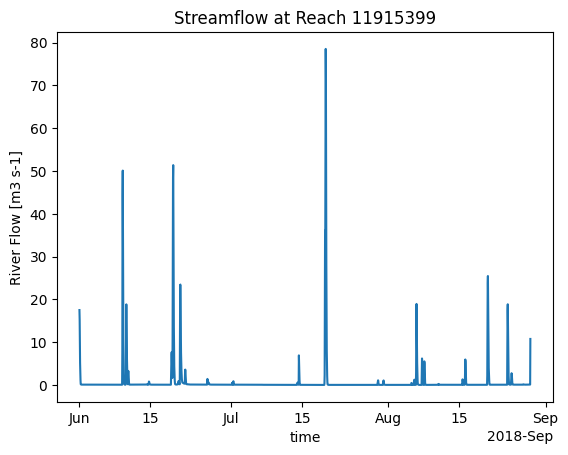

In [25]:
feature_id = 11915399
ax = ds.sel(feature_id=feature_id).streamflow.plot(label='Streamflow (cms)')
ax[0].axes.set_title(f'Streamflow at Reach {feature_id}');

In [26]:
ds = load_kerchunk_from_hs(resource, 'LDASOUT_references.json')
ds

<xarray.Dataset> Size: 873MB
Dimensions:         (time: 2137, y: 12, x: 38, snow_layers: 3,
                     soil_layers_stag: 4, reference_time: 1)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 8B 2018-06-01
  * time            (time) datetime64[ns] 17kB 2018-06-01 ... 2018-08-29
  * x               (x) float64 304B 3.995e+05 4.005e+05 ... 4.355e+05 4.365e+05
  * y               (y) float64 96B -2.035e+05 -2.025e+05 ... -1.925e+05
Dimensions without coordinates: snow_layers, soil_layers_stag
Data variables: (12/96)
    ACCECAN         (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    ACCEDIR         (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    ACCET           (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    ACCETRAN        (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    ACCPRCP         (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    ACSNOM          (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    ...              ...
    WA              (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    WOOD            (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    WT              (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    ZSNSO_SN        (time, y, snow_layers, x) float64 23MB dask.array<chunksize=(712, 12, 3, 38), meta=np.ndarray>
    ZWT             (time, y, x) float64 8MB dask.array<chunksize=(712, 12, 38), meta=np.ndarray>
    crs             object 8B ...
Attributes:
    TITLE:                      OUTPUT FROM WRF-Hydro v5.0.0
    model_initialization_time:  2018-06-01_00:00:00
    model_output_valid_time:    2018-06-01_00:00:00
    model_total_valid_times:    2136
    Conventions:                CF-1.6
    model_version:              WRF-Hydro v5.0.0
    model_output_type:          land
    model_configuration:        default
    proj4:                       
    GDAL_DataType:              Generic
    history:                    Tue Aug  5 15:48:12 2025: ncrcat -O OUTPUT/20...
    NCO:                        netCDF Operators version 5.3.4 (Homepage = ht...

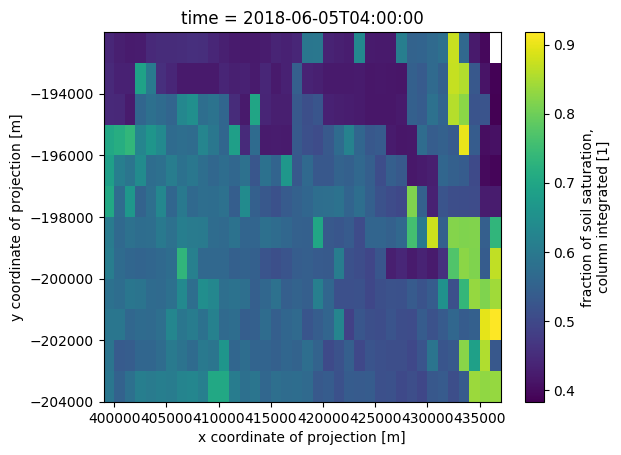

In [28]:
ds.isel(time=100).SOILSAT.plot()